In this notebook, we test an impact of downsampling on filters' estimations by comparing pre-downsampling and post-downsampling results.
The dataset used in this test is KITTI raw dataset sequence 09.

In [1]:
import os
import sys
sys.path.append('/app/src')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import seaborn as sns
import random
from tqdm import tqdm
from enum import Enum
from sklearn.metrics import mean_squared_error
from filterpy.monte_carlo import (
    multinomial_resample, residual_resample, systematic_resample, stratified_resample
)
from utils.error_report import get_error_from_list
from data_loader import DataLoader
from configs.configs import MeasurementDataEnum, SetupEnum, SamplingEnum, ErrorEnum
import scipy.stats as stats
from scipy.stats import multivariate_normal
from kalman_filters import (
    ExtendedKalmanFilter,
    UnscentedKalmanFilter,
    ParticleFilter, ResamplingAlgorithms,
    EnsembleKalmanFilter,
    CubatureKalmanFilter
)
from numpy.linalg import norm


%matplotlib inline
np.random.seed(777)

# Load dataset

In [2]:
root_path = '../../../../'
kitti_root_dir = os.path.join(root_path, "data")
vo_root_dir = os.path.join(root_path, "vo_estimates")
noise_vector_dir = os.path.join(root_path, "exports/_noise_optimizations/noise_vectors")
kitti_date = '2011_09_30'
kitti_drive = '0033'

data = DataLoader(sequence_nr=kitti_drive, 
                  kitti_root_dir=kitti_root_dir, 
                  vo_root_dir=vo_root_dir,
                  noise_vector_dir=noise_vector_dir,
                  vo_dropout_ratio=0.0, 
                  gps_dropout_ratio=0.0)

In [5]:
x_setup1, P_setup1, H_setup1 = data.get_initial_data(setup=SetupEnum.SETUP_1)
x_setup2, P_setup2, H_setup2 = data.get_initial_data(setup=SetupEnum.SETUP_2)
x_setup3, P_setup3, H_setup3 = data.get_initial_data(setup=SetupEnum.SETUP_3)

n_samples = 2048
resampling_algorithm = ResamplingAlgorithms.STRATIFIED

Data is sampled and synchronized at 8Hz.
Shapes after downsampling
time: (1272,)
GPS: (1272, 3)
INS: (1272, 3)
IMU (angular vel): (1272, 3)
IMU (linear acc): (1272, 3)
Data sampling is set to downsampling mode.
[PF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 1271/1271 [01:04<00:00, 19.83it/s]


[PF] errors: {<ErrorEnum.MAE: 1>: 0.303, <ErrorEnum.RMSE: 2>: 0.379, <ErrorEnum.MAX: 3>: 1.348}


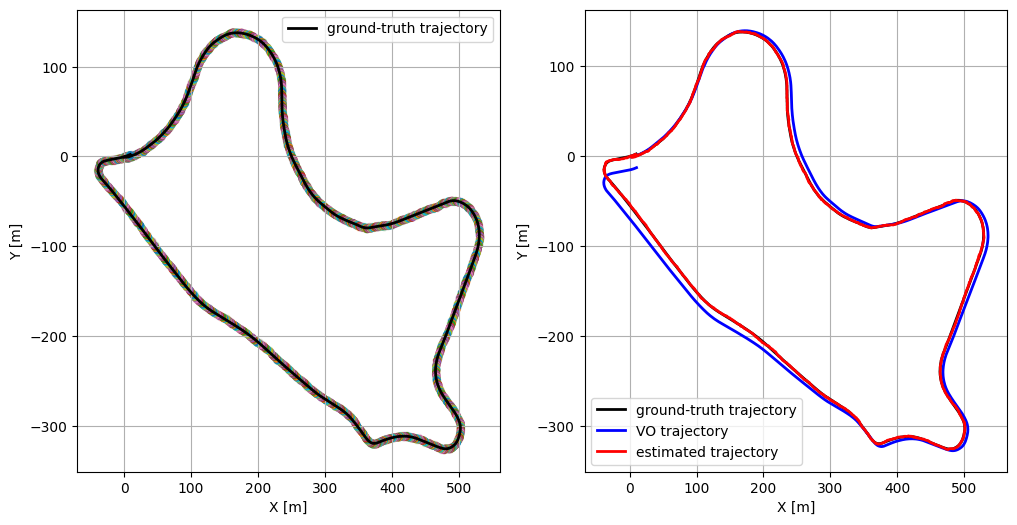

In [8]:
data.set_downsampling_ratio(ratio=0.2)
data.set_data_sampling(sampling=SamplingEnum.DOWNSAMPLED_DATA)

pf3 = ParticleFilter(N=n_samples, 
                     x_dim=x_setup3.shape[0], 
                     H=H_setup3.copy(), 
                     resampling_algorithm=resampling_algorithm)
pf3.create_gaussian_particles(mean=x_setup3.copy(), var=P_setup3.copy())

error_pf3 = pf3.run(data=data, 
                    setup=SetupEnum.SETUP_3,
                    debug_mode=True,
                    show_graph=True)

[PF] start.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 158/158 [00:08<00:00, 19.49it/s]


[PF] errors: {<ErrorEnum.MAE: 1>: 0.848, <ErrorEnum.RMSE: 2>: 1.06, <ErrorEnum.MAX: 3>: 3.44}


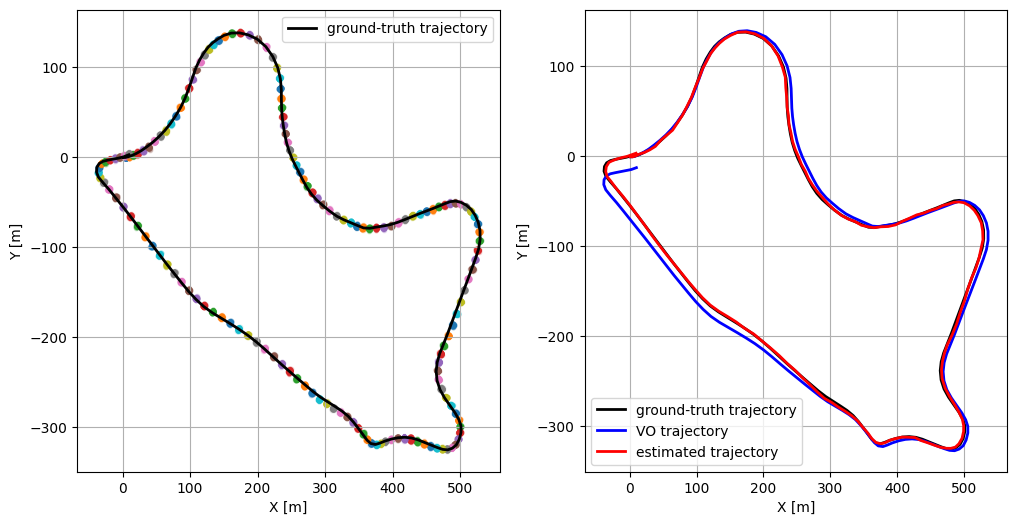

In [7]:
data.set_downsampling_ratio(ratio=0.9)
data.set_data_sampling(sampling=SamplingEnum.DOWNSAMPLED_DATA)
pf3 = ParticleFilter(N=n_samples, 
                     x_dim=x_setup3.shape[0], 
                     H=H_setup3.copy(), 
                     resampling_algorithm=resampling_algorithm)
pf3.create_gaussian_particles(mean=x_setup3.copy(), var=P_setup3.copy())

error_pf3 = pf3.run(data=data, 
                    setup=SetupEnum.SETUP_3,
                    debug_mode=True,
                    show_graph=True)

Data is sampled and synchronized at 1Hz.
Shapes after downsampling
time: (159,)
GPS: (159, 3)
INS: (159, 3)
IMU (angular vel): (159, 3)
IMU (linear acc): (159, 3)
Data sampling is set to downsampling mode.
[EKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 158/158 [00:00<00:00, 7093.39it/s]

[EKF] errors: {<ErrorEnum.MAE: 1>: 2.892, <ErrorEnum.RMSE: 2>: 3.61, <ErrorEnum.MAX: 3>: 10.698}


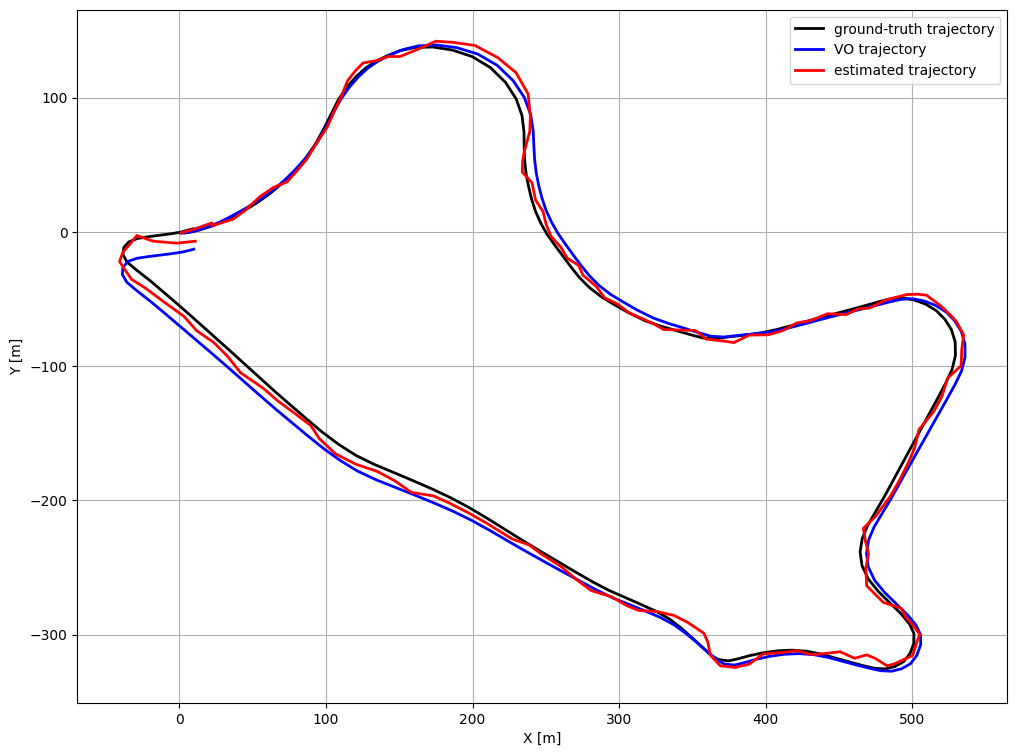

In [9]:
data.set_downsampling_ratio(ratio=0.9)
data.set_data_sampling(sampling=SamplingEnum.DOWNSAMPLED_DATA)
ekf2 = ExtendedKalmanFilter(x=x_setup2.copy(), 
                                P=P_setup2.copy(), 
                                H=H_setup2.copy())
pf3.create_gaussian_particles(mean=x_setup3.copy(), var=P_setup3.copy())

error_ekf2 = ekf2.run(data=data, 
                      setup=SetupEnum.SETUP_2,
                      debug_mode=True,
                      show_graph=True
                     )

Data is sampled and synchronized at 1Hz.
Shapes after downsampling
time: (159,)
GPS: (159, 3)
INS: (159, 3)
IMU (angular vel): (159, 3)
IMU (linear acc): (159, 3)
Data sampling is set to downsampling mode.
[CKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 158/158 [00:00<00:00, 1946.87it/s]

[CKF] errors: {<ErrorEnum.MAE: 1>: 7.818, <ErrorEnum.RMSE: 2>: 12.759, <ErrorEnum.MAX: 3>: 46.702}


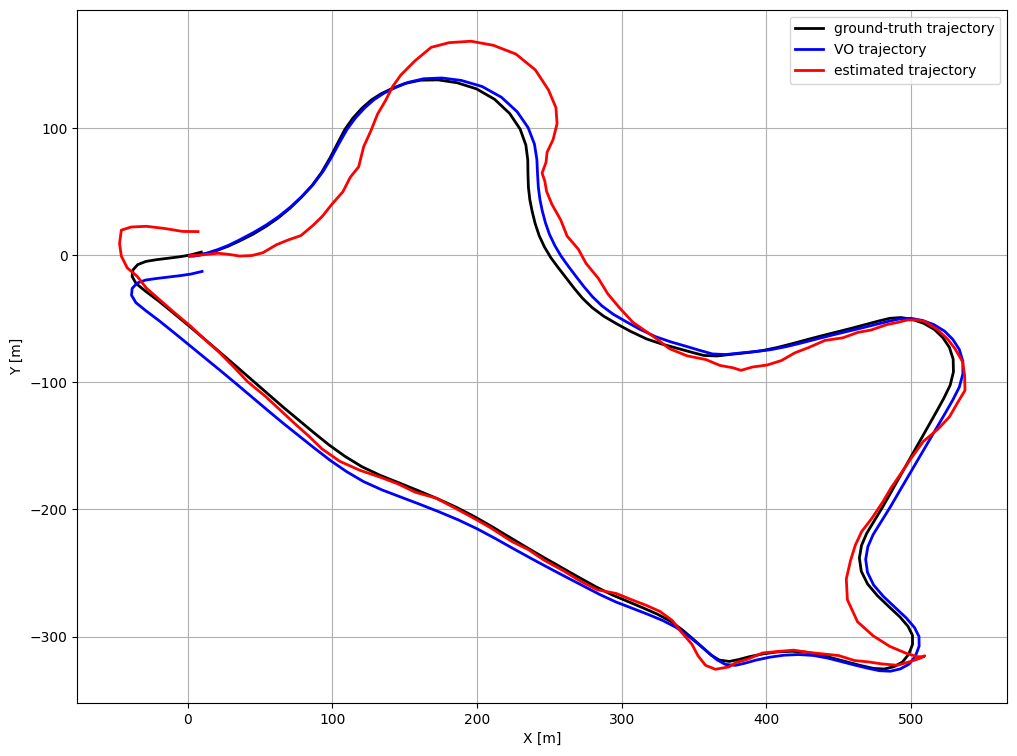

In [10]:
data.set_downsampling_ratio(ratio=0.9)
data.set_data_sampling(sampling=SamplingEnum.DOWNSAMPLED_DATA)
ckf2_0 = CubatureKalmanFilter(x=x_setup2.copy(), 
                              P=P_setup2.copy(), 
                              H=H_setup2.copy())

error_ckf2_0 = ckf2_0.run(
        data=data, 
        setup=SetupEnum.SETUP_2, 
        debug_mode=True,
        show_graph=True
    )